# Digit Recognition for Optical Sudoku Solver

This notebook trains a Support Vector Machine (SVM) classifier to recognize printed digits (1–9) from extracted Sudoku cell images.

**Pipeline:**
1. Download and prepare the Chars74K `EnglishFnt` dataset
2. Preprocess images and extract HOG features
3. Train and evaluate an SVM classifier
4. Export the trained model to `models/digit_model.pkl`

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import joblib
import ssl
import tarfile
import urllib.error
import urllib.request


from utils import normalize_cell, HOG_PARAMS, extract_hog_features, extract_lbp_features, extract_features

In [2]:
# ── Dataset path ────────────────────────────────────────────────────────────
CHARS74K_PATH = os.path.join("data", "English", "Fnt")

## 1. Dataset Setup

The [Chars74K](http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/) dataset contains computer-rendered characters across 1,016 fonts. We use the `EnglishFnt` subset, which covers digits and letters in clean typeset form — well-matched to printed Sudoku puzzles.

The cell below downloads and extracts the dataset into `data/` automatically if it is not already present.

In [3]:


DATASET_URL = "http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/EnglishFnt.tgz"
ARCHIVE_PATH = os.path.join("data", "EnglishFnt.tgz")

def print_download_progress(downloaded, total_size):
    if total_size and total_size > 0:
        percent = min(downloaded / total_size * 100, 100)
        print(f"\rDownloading Chars74K... {percent:.1f}%", end="", flush=True)
    else:
        mb = downloaded / (1024 * 1024)
        print(f"\rDownloading Chars74K... {mb:.1f} MB", end="", flush=True)

def download_file(url, destination, ssl_context=None):
    with urllib.request.urlopen(url, context=ssl_context) as response, open(destination, "wb") as out_file:
        total_size = response.headers.get("Content-Length")
        total_size = int(total_size) if total_size is not None else None
        downloaded = 0
        while True:
            chunk = response.read(1024 * 64)
            if not chunk:
                break
            out_file.write(chunk)
            downloaded += len(chunk)
            print_download_progress(downloaded, total_size)
    print()

if not os.path.exists(CHARS74K_PATH):
    os.makedirs("data", exist_ok=True)
    print("Downloading Chars74K EnglishFnt dataset...")
    try:
        download_file(DATASET_URL, ARCHIVE_PATH)
    except urllib.error.URLError as err:
        reason = getattr(err, "reason", None)
        if isinstance(reason, ssl.SSLCertVerificationError):
            print("SSL verification failed. Retrying without certificate verification for this download...")
            insecure_context = ssl._create_unverified_context()
            download_file(DATASET_URL, ARCHIVE_PATH, ssl_context=insecure_context)
        else:
            raise
    print("\nExtracting...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall("data")
    os.remove(ARCHIVE_PATH)
    print(f"Chars74K ready at: {CHARS74K_PATH}")
else:
    print(f"Chars74K already present at: {CHARS74K_PATH}")

SSL verification failed. Retrying without certificate verification for this download...

Extracting...
Chars74K ready at: data/English/Fnt


## 2. Data Loading and Preprocessing

This notebook trains only on **Chars74K `EnglishFnt`**.

We load digits 1-9, resize each image to **40×40 pixels** to match `Image_Processing.ipynb`, and run `normalize_cell()` to center the digit on a clean canvas before feature extraction.

In [4]:
CELL_SIZE = 40  # must match the cell size produced by Image_Processing.ipynb

images = []
labels = []

# ── Chars74K ────────────────────────────────────────────────────────────────
# Sample001 = '0', Sample002 = '1', ..., Sample010 = '9'
DIGIT_SAMPLES = {digit: f"Sample{digit + 1:03d}" for digit in range(1, 10)}

for digit, sample_folder in DIGIT_SAMPLES.items():
    folder_path = os.path.join(CHARS74K_PATH, sample_folder)
    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith(".png"):
            continue
        img = cv2.imread(os.path.join(folder_path, fname), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (CELL_SIZE, CELL_SIZE))
        img = normalize_cell(img)
        if img.max() == 0:  # normalization failed — faint/empty glyph, skip
            continue
        images.append(img)
        labels.append(digit)

print(f"Chars74K samples loaded: {len(images)}")
print(f"\nTotal samples before augmentation: {len(images)}")

images = np.array(images)
labels = np.array(labels)

Chars74K samples loaded: 9144

Total samples before augmentation: 9144


In [6]:
# browser.next()
#1007, 1045

# completely wrong
# 1020, 1040, 1062, 109, 112, 114, 119, 122, 126

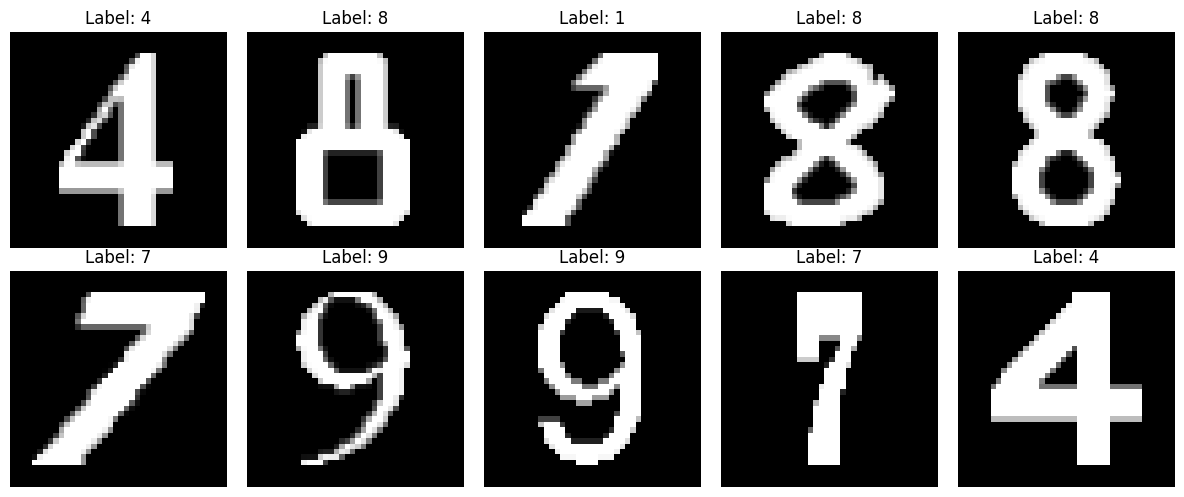

In [7]:
# display some images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax in axes.flatten():
    idx = np.random.randint(len(images))
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"Label: {labels[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Data Augmentation

To bridge the gap between clean Chars74K fonts and real scanned Sudoku images, we generate **3 augmented copies** of every training image — giving 4× the training data (~36,576 samples total).

Each augmented copy randomly applies rotation, erosion/dilation, Gaussian blur, and salt-and-pepper noise via `augment_image()` from `utils.py`.

In [8]:
from utils import augment_image

AUGMENTATIONS_PER_IMAGE = 3
rng = np.random.default_rng(seed=42)

aug_images = []
aug_labels = []

for img, label in zip(images, labels):
    for _ in range(AUGMENTATIONS_PER_IMAGE):
        aug_images.append(augment_image(img, rng=rng))
        aug_labels.append(label)

images = np.concatenate([images, np.array(aug_images)])
labels = np.concatenate([labels, np.array(aug_labels)])

print(f"Total samples after augmentation: {len(images)}")
print(f"Samples per digit: {len(images) // 9}")

Total samples after augmentation: 36576
Samples per digit: 4064


Digit 1: using sample index 0 for visualization
Digit 2: using sample index 1016 for visualization
Digit 3: using sample index 2032 for visualization
Digit 4: using sample index 3048 for visualization
Digit 5: using sample index 4064 for visualization
Digit 6: using sample index 5080 for visualization
Digit 7: using sample index 6096 for visualization
Digit 8: using sample index 7112 for visualization
Digit 9: using sample index 8128 for visualization


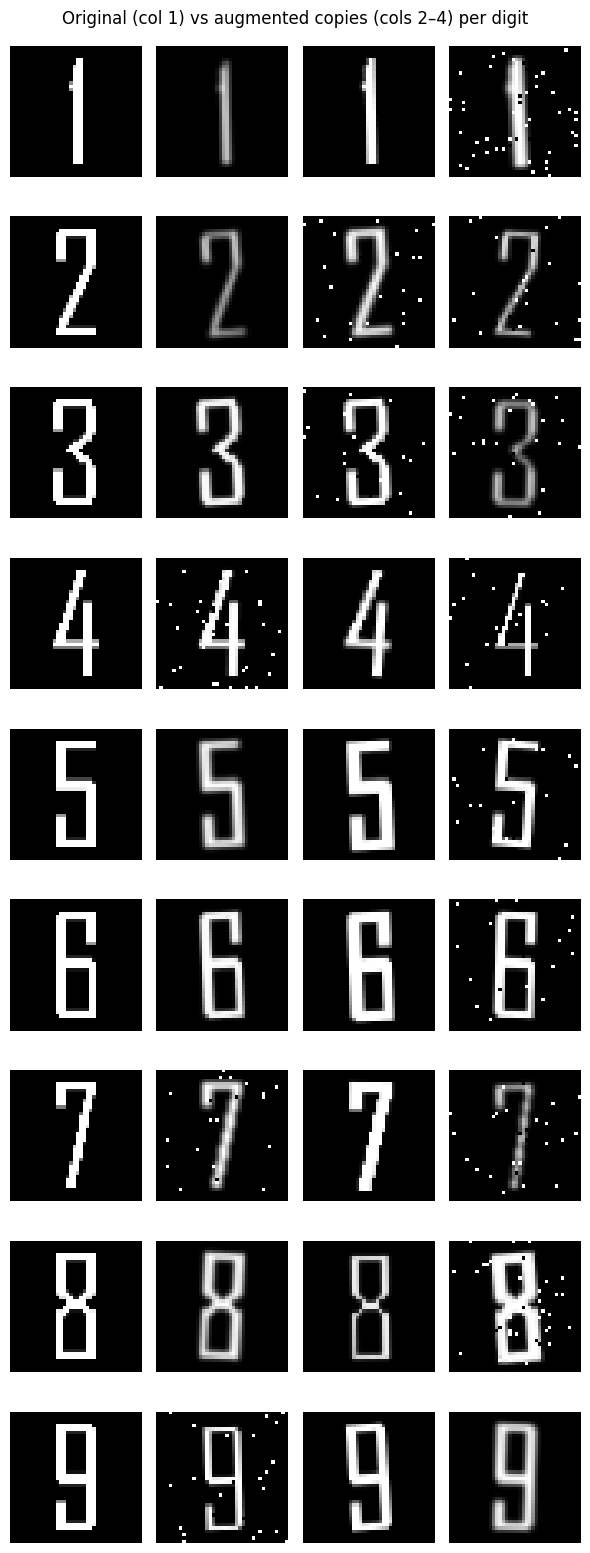

In [9]:
# Show original vs 3 augmented versions for one sample of each digit
fig, axes = plt.subplots(9, 4, figsize=(6, 16))
fig.suptitle("Original (col 1) vs augmented copies (cols 2–4) per digit", fontsize=12)

vis_rng = np.random.default_rng(seed=0)
for row, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    # Pick the first non-black sample for a clean visualization
    idx = next((i for i in digit_indices if images[i].max() > 0), digit_indices[0])
    original = images[idx]
    print(f"Digit {digit}: using sample index {idx} for visualization")
    axes[row, 0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_ylabel(str(digit), fontsize=11, rotation=0, labelpad=12)
    axes[row, 0].axis("off")
    for col in range(1, 4):
        aug = augment_image(original, rng=vis_rng)
        axes[row, col].imshow(aug, cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

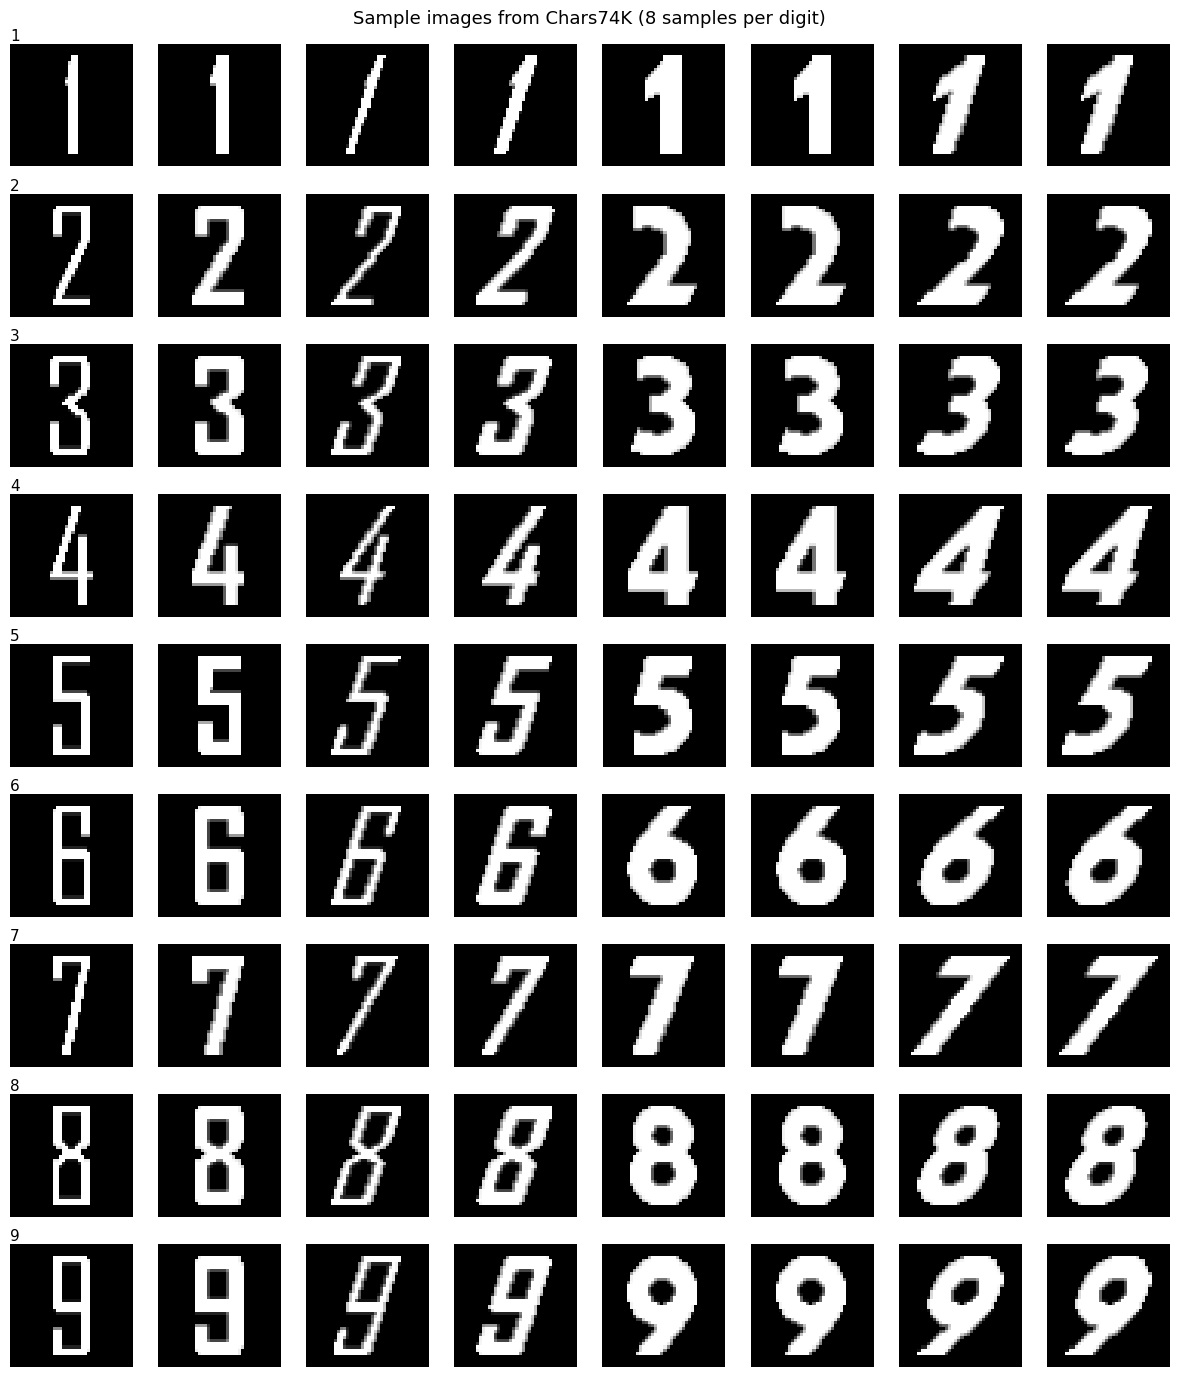

In [10]:
fig, axes = plt.subplots(9, 8, figsize=(12, 14))
fig.suptitle("Sample images from Chars74K (8 samples per digit)", fontsize=13)

for row, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    sample_indices = digit_indices[:8]
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(images[idx], cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(str(digit), fontsize=11, loc="left", pad=2)

plt.tight_layout()
plt.show()

## 3. Feature Extraction — HOG + LBP

We combine two complementary feature descriptors to improve discrimination between visually similar digits (3, 6, 8, 9):

**HOG (Histogram of Oriented Gradients)** — captures edge directions and shape structure.
- `pixels_per_cell=(4, 4)` — 10×10 grid of cells on a 40×40 image (finer than 8×8, picks up more local detail)
- `cells_per_block=(2, 2)`, `orientations=9`
- Produces **2,916 features**

**LBP (Local Binary Pattern)** — captures local texture topology (open vs closed loops).
- `P=8, R=1, method="uniform"` — 59 unique pattern bins
- Computed over a 4×4 spatial grid of regions for positional awareness
- Produces **944 features** (4 × 4 × 59)

**Combined feature vector: 3,860 dimensions**

In [11]:
X = extract_features(images)
y = labels

print(f"Feature matrix shape     : {X.shape}")
print(f"HOG features per image   : {extract_hog_features(images[:1]).shape[1]}")
print(f"LBP features per image   : {extract_lbp_features(images[:1]).shape[1]}")
print(f"Combined features/image  : {X.shape[1]}")

Feature matrix shape     : (36576, 3860)
HOG features per image   : 2916
LBP features per image   : 944
Combined features/image  : 3860


### HOG Visualization

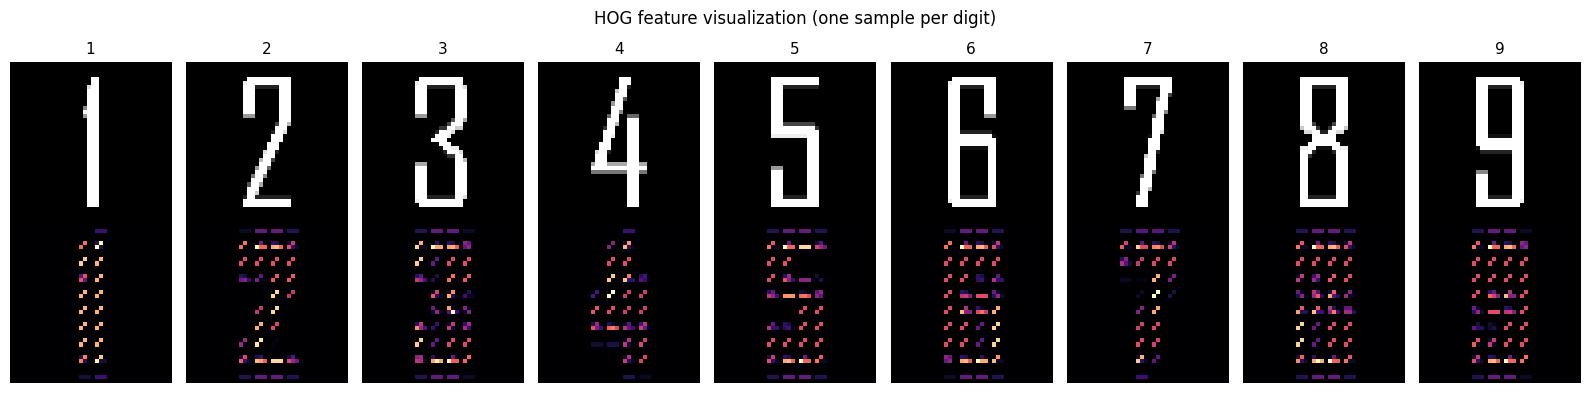

In [12]:
from skimage.feature import hog as skimage_hog

fig, axes = plt.subplots(2, 9, figsize=(16, 4))
fig.suptitle("HOG feature visualization (one sample per digit)", fontsize=12)

for col, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    # Pick the first non-black sample for a clean visualization
    idx = next((i for i in digit_indices if images[i].max() > 0), digit_indices[0])
    img_norm = images[idx].astype(np.float32) / 255.0
    _, hog_image = skimage_hog(img_norm, **HOG_PARAMS, visualize=True)

    axes[0, col].imshow(images[idx], cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(str(digit), fontsize=11)
    axes[0, col].axis("off")

    axes[1, col].imshow(hog_image, cmap="magma")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("HOG", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Class distribution check
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining samples per digit:")
for d, c in zip(unique, counts):
    print(f"  Digit {d}: {c}")

Training samples : 29260
Test samples     : 7316

Training samples per digit:
  Digit 1: 3251
  Digit 2: 3251
  Digit 3: 3251
  Digit 4: 3251
  Digit 5: 3251
  Digit 6: 3251
  Digit 7: 3251
  Digit 8: 3252
  Digit 9: 3251


## 5. SVM Training

We train a Support Vector Machine with an **RBF (radial basis function) kernel**. RBF is well-suited for HOG features because it can model the non-linear boundaries between digit classes.

**Hyperparameters:**
- `C=10` — regularization strength; penalizes misclassifications (higher = tighter fit)
- `gamma='scale'` — sets the RBF kernel width automatically based on feature variance

In [14]:
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train, y_train)
print("SVM training complete.")

SVM training complete.


### Cross-Validation

5-fold cross-validation on the training set gives an unbiased estimate of generalization accuracy before we touch the test set.

In [15]:
# from sklearn.model_selection import cross_val_score

# cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
# print(f"Cross-validation accuracy (5-fold): {cv_scores}")
# print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

### Test Set Evaluation

In [16]:
y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=[str(d) for d in range(1, 10)]))

              precision    recall  f1-score   support

           1       0.99      0.99      0.99       813
           2       1.00      1.00      1.00       813
           3       1.00      1.00      1.00       813
           4       1.00      1.00      1.00       813
           5       1.00      1.00      1.00       813
           6       1.00      1.00      1.00       813
           7       0.99      0.99      0.99       813
           8       1.00      1.00      1.00       812
           9       1.00      1.00      1.00       813

    accuracy                           1.00      7316
   macro avg       1.00      1.00      1.00      7316
weighted avg       1.00      1.00      1.00      7316



### Confusion Matrix

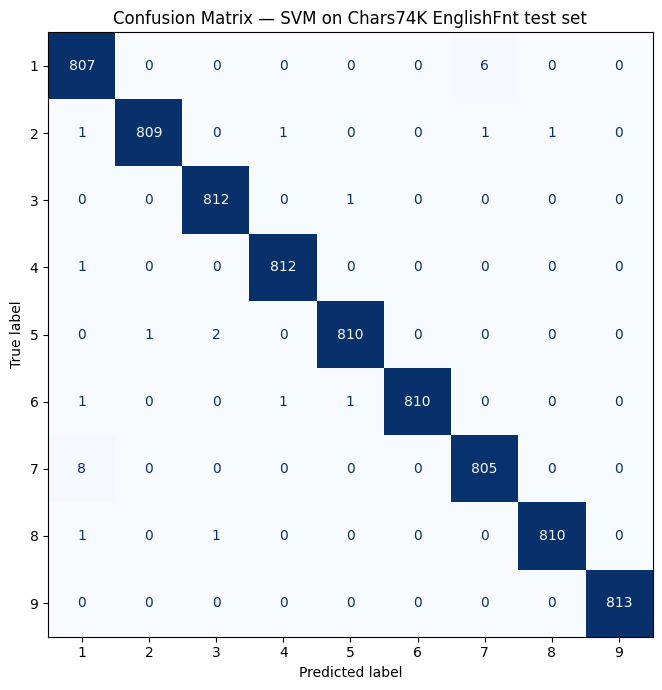

In [17]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — SVM on Chars74K EnglishFnt test set")
plt.tight_layout()
plt.show()

## 6. Export Model

Save the trained model to `models/digit_model.pkl` for use in `Image_Processing.ipynb`.

In [18]:
os.makedirs("models", exist_ok=True)
joblib.dump(svm, "models/digit_model.pkl")
print("Model saved to models/digit_model.pkl")

Model saved to models/digit_model.pkl
